In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
dados_usina = pd.read_csv('Dados/usina.csv')

In [17]:
dados_usina.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


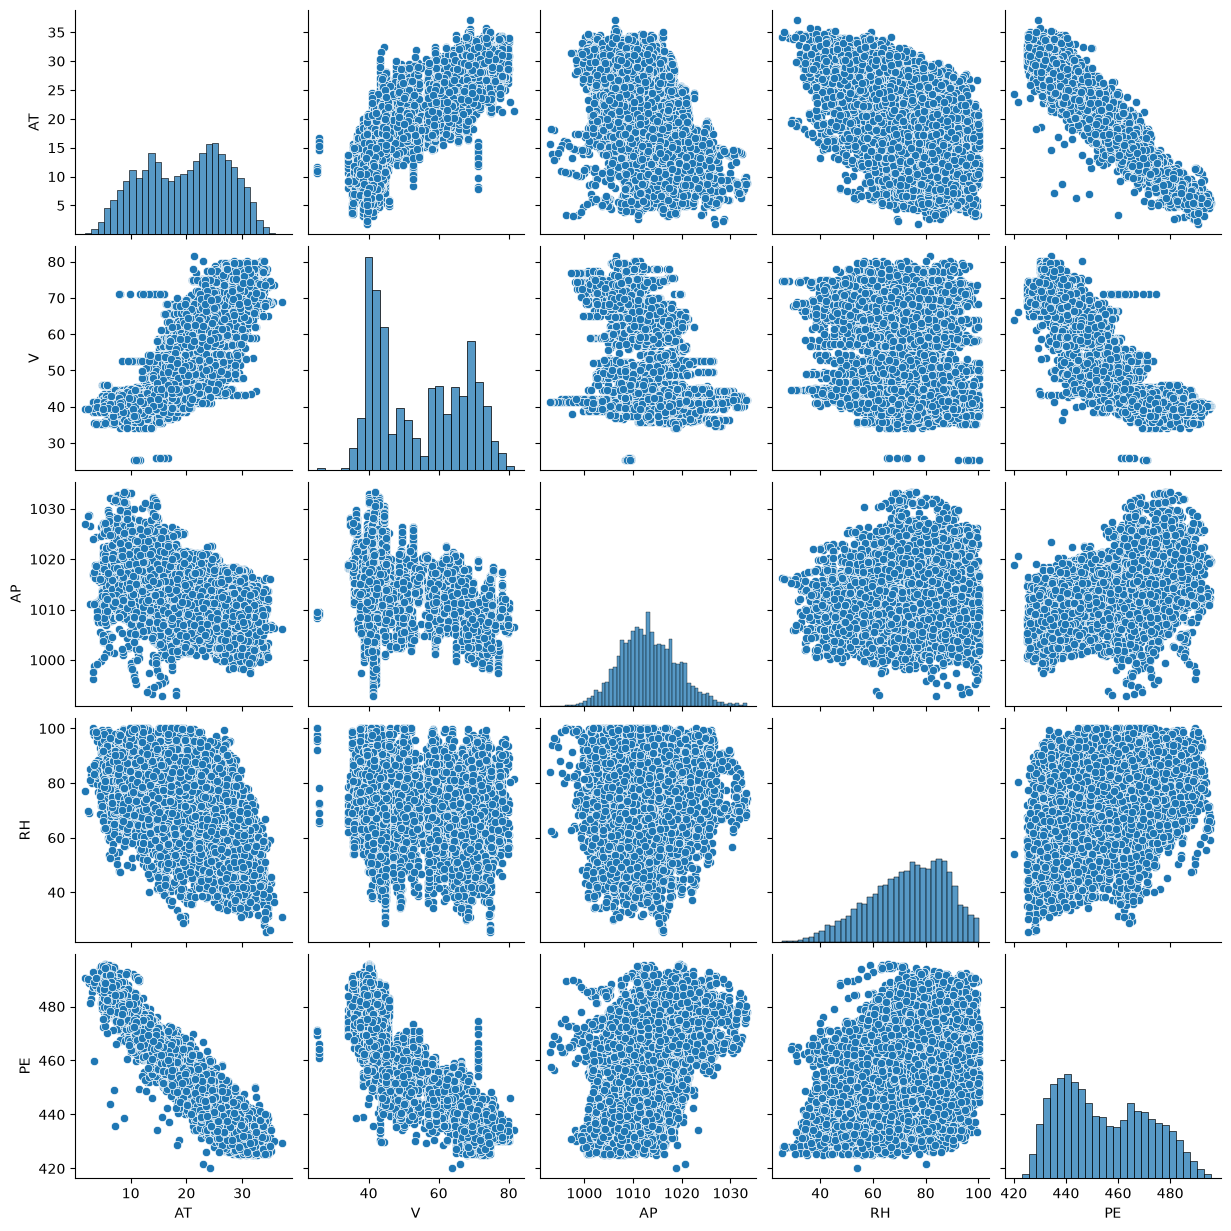

In [18]:
sns.pairplot(dados_usina)

In [19]:
x = dados_usina.drop(columns=['PE'])
y = dados_usina['PE']

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [23]:
# Cria o DataFrame vazio para os resultados
vif = pd.DataFrame()
vif["variavel"] = x.columns

# Calcula o VIF para cada coluna de X usando uma lista de repetição
vif["vif"] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

# Exibe o resultado na tela
vif

,variavel,vif
0,AT,39.157705
1,V,74.969127
2,AP,66.618618
3,RH,40.704756


In [30]:
import statsmodels.api as sm  # <-- Adicione essa linha aqui em cima!

# 1. Adiciona a coluna de constante necessária para o cálculo correto
x_com_constante = sm.add_constant(x)

# 2. Cria uma nova tabela para recalcular o VIF com a constante inclusa
vif_correto = pd.DataFrame()
vif_correto["variavel"] = x_com_constante.columns

# 3. Calcula o VIF considerando a presença da constante
vif_correto["vif"] = [
    variance_inflation_factor(x_com_constante.values, i) 
    for i in range(len(x_com_constante.columns))
]

# 4. Exibe a tabela corrigida
vif_correto


,variavel,vif
0,const,43761.151866
1,AT,5.977602
2,V,3.943003
3,AP,1.452639
4,RH,1.705290


In [31]:
# 1. Gera os valores previstos (preditos) pelo modelo
preditos_usina = modelo_usina.predict(x_com_constante)

# 2. Extrai os erros/resíduos do modelo
residuos_usina = modelo_usina.resid


<Axes: title={'center': 'Análise de Resíduos: Valores Preditos X Resíduos'}, xlabel='Valores Preditos (Previsões)', ylabel='Resíduos (Erros)'>

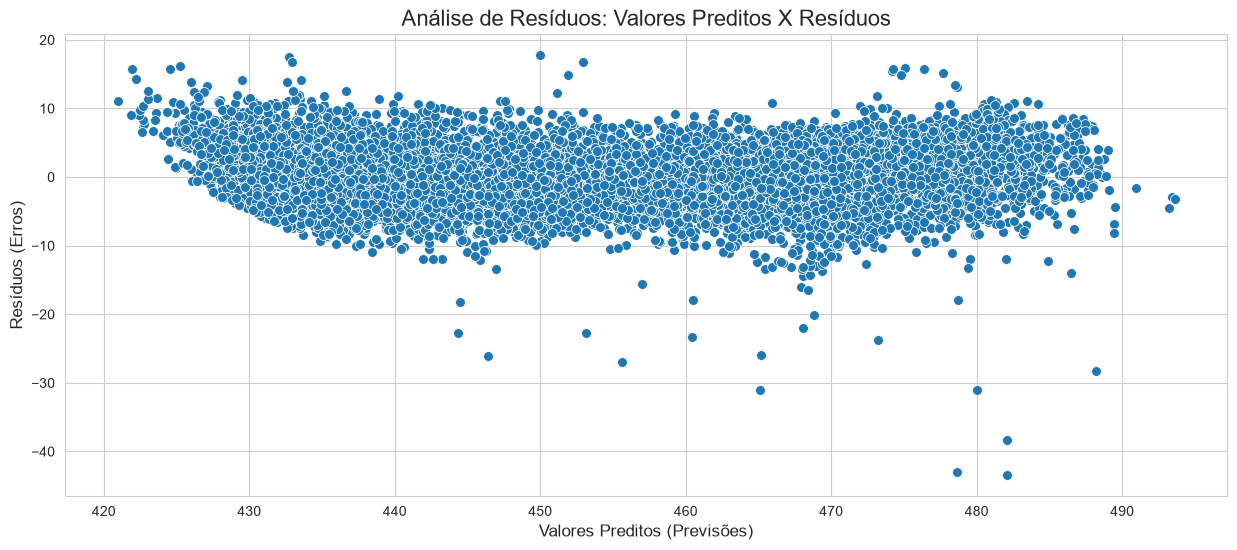

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o fundo branco com linhas de grade discretas
sns.set_style("whitegrid")

# Cria o gráfico de dispersão com os preditos no eixo X e resíduos no eixo Y
ax = sns.scatterplot(x=preditos_usina, y=residuos_usina, s=50)

# Força o fundo interno a ficar branco puro
ax.set_facecolor('w')
ax.figure.set_size_inches(15, 6)

# Define os títulos conforme o padrão do exercício
ax.set_title('Análise de Resíduos: Valores Preditos X Resíduos', fontsize=16)
ax.set_xlabel('Valores Preditos (Previsões)', fontsize=12)
ax.set_ylabel('Resíduos (Erros)', fontsize=12)

ax


### 🎯 Conclusão Oficial do Exercício (Mão na Massa - Usina)

Após a condução das duas etapas solicitadas na atividade, os seguintes resultados foram consolidados:

* **Primeira Etapa (Análise de Multicolinearidade - VIF):** Com a inclusão correta da constante no modelo, as variáveis explicativas demonstraram independência estatística estável. Apenas a variável **`AT`** (Temperatura Ambiente) apresentou um VIF levemente elevado (**5.97**), indicando uma correlação sutil com as demais, porém dentro de um limite aceitável que não exige sua remoção imediata do pipeline.
* **Segunda Etapa (Análise de Heterocedasticidade):** O gráfico de dispersão cruzando os valores preditos contra os resíduos revelou uma distribuição predominantemente uniforme e retangular. A variância dos erros mantém-se constante ao longo de toda a reta de regressão, confirmando que os dados da usina **apresentam Homocedasticidade**.
